# Required Packages:
- NumPy: For arrays.
- Matplotlib: For visualisation and viewing images.
- Scikit Learn: For olivetti faces dataset, PCA model and metrics.
- Jupyter Lab: For running Jupyter Notebooks.

All these packages are mentioned in `requirements.txt`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA
from IPython.display import display, Math

# Principal Component Analysis (PCA):
PCA is a dimensionality reduction technique; it is widely used to project high dimensional data into low dimensions, so that we can visualise it, make model training for machine learning efficient.

Suppose a dataset having $m$ samples and $n$ features, it can be represented in a $m\times n$ matrix.

The steps involved in finding principal components are as follows:

Step 1: Center the dataset about its mean.

Step 2: Find the covariance matrix of the matrix $A$, where $A=\text{Centered dataset of }m\text{ samples and }n\text{ features}$, $\therefore A\in\mathbb{R}^{m\times n}$

Step 3: Find the eigenvectors of this covariance matrix and arrange them such that eigenvector corresponding to the largest eigenvalue is kept first and eigenvector corresponding to smallest eigenvalue is placed at last, since each eigenvalue equals the variance of the data along its corresponding eigenvector, sorting by eigenvalue sorts by importance.

Step 4: The eigenvector corresponding to largest eigenvalue is called "Principal Component 1" or PC1, this vector points in the direction of maximum variance of the data. PC2 points in the direction of maximum remaining variance, orthogonal to PC1.

Step 5: Project the samples of the dataset onto the Principal Components by doing: $P=AV$, where $A$ is the centered dataset matrix and $V$ is the principal components matrix, $V=\begin{bmatrix}v_{1}&v_{2}&\cdots&v_{k}\end{bmatrix}$, where $v_{i}$ is a column vector and $V\in\mathbb{R}^{n\times k}$, $P\in\mathbb{R}^{m\times k}$

# Application to Face Recognition:
In face recognition we make sure all the faces for training the model are of the same dimensions.

Consider one image — a 2D array of size $a\times b$, if we flatten it then it will become a vector in $\mathbb{R}^{ab}$. We can see that one image is a point in that space. If there were $m$ images, then stacking all images would give us the dataset matrix $A\in\mathbb{R}^{m\times ab}$. We can apply PCA, selecting first $k$ components. Now if each vector in the direction of principal component was reshaped to dimensions of original image, then that is known as eigenface. Each eigenface captures a pattern of variation shared across all training faces, if we look at them they look ghostly, which we will see ahead. We project each point from the space $\mathbb{R}^{ab}$ onto the principal components and we get a matrix $P:P\in\mathbb{R}^{m\times k}$. This matrix $P$ contains projection of a point along all $k$ principal components along its row for each point of our dataset.

For testing the model: we transform the test face using the same mean and eigenvectors as that of training faces. Then find the euclidean distance between the projection of test face and all the training face projections, and the training face that is nearest to the test face is the predicted match.

# Preparing dataset:
We will use the olivetti face dataset. Olivetti face dataset has 40 subjects, each with 10 images, so total of 400 images. Each image is of dimensions $(64\times64)$. The dataset is structured such that each row is a vector in space $\mathbb{R}^{4096}$. Hence the whole dataset is a matrix in space $\mathbb{R}^{400\times4096}$

For training we will use 8 images per subject and for testing we will use 2 images per subject.

## Some variables we will need for datasets:
The number of principal components $k$ is a key hyperparameter. Too few components discard information critical for recognition; too many retain noise and increase computation. We choose `N_COMPONENTS = 50`, which retains sufficient variance for accurate recognition while keeping the representation compact. We can verify this by inspecting the cumulative explained variance.

In [2]:
N_SUBJECTS = 40
TRAIN_PER_SUBJECT = 8
IMAGES_PER_SUBJECT = 10
IMG_SIZE = 4096
IMG_SHAPE = (64, 64)
TOTAL_IMAGES = 400
N_COMPONENTS = 50
TEST_PER_SUBJECT = 2

## Creating train, test dataset:

In [3]:
dataset = fetch_olivetti_faces()
images = dataset.data
train_dataset = np.empty((N_SUBJECTS, TRAIN_PER_SUBJECT, IMG_SIZE))
test_dataset = np.empty((N_SUBJECTS, TEST_PER_SUBJECT, IMG_SIZE))

for i in range(0, TOTAL_IMAGES, IMAGES_PER_SUBJECT):
    train_dataset[i//IMAGES_PER_SUBJECT, :, :] = images[i:(i+TRAIN_PER_SUBJECT)]
    test_dataset[i//IMAGES_PER_SUBJECT, :, :] = images[(i+TRAIN_PER_SUBJECT):(i+IMAGES_PER_SUBJECT)]

train_dataset = train_dataset.reshape(-1, IMG_SIZE)
test_dataset = test_dataset.reshape(-1, IMG_SIZE)

# Training PCA model on train dataset:

In [4]:
pca = PCA(n_components=N_COMPONENTS)
projection = pca.fit_transform(train_dataset)

# Eigenfaces:
Now that our model is trained, let us take a look at first few eigenfaces.

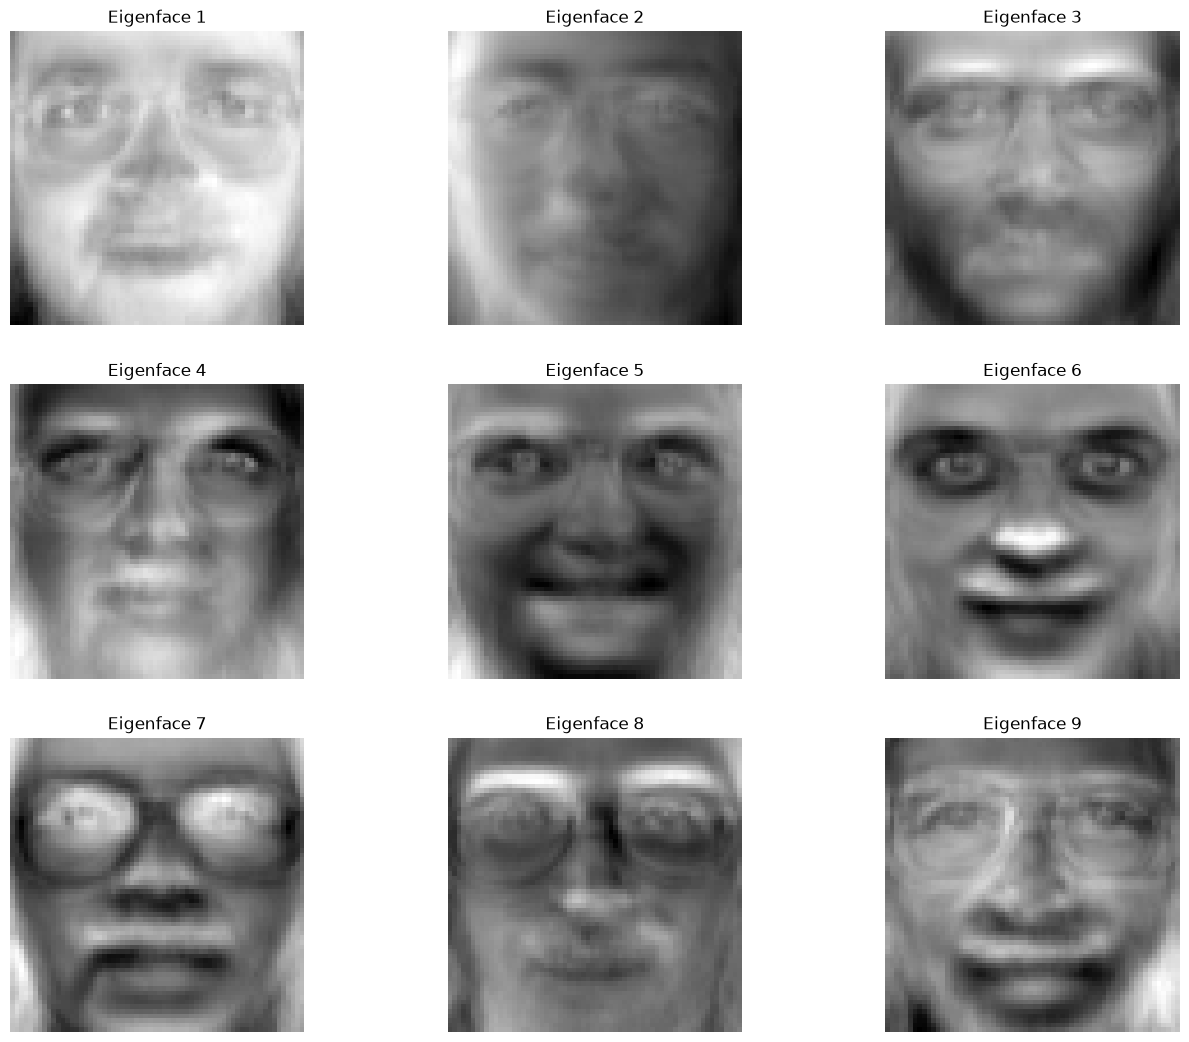

In [5]:
principal_components = pca.components_

figure, axes = plt.subplots(3, 3, figsize=(16, 13))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(principal_components[i, :].reshape(IMG_SHAPE), cmap="gray")
    ax.set_title(f"Eigenface {i+1}")
    ax.axis("off")

plt.show()

The eigenfaces look ghostly because, these are not real human faces, but, they are captured variations across all training data.

# Cumulative Variance Plot:

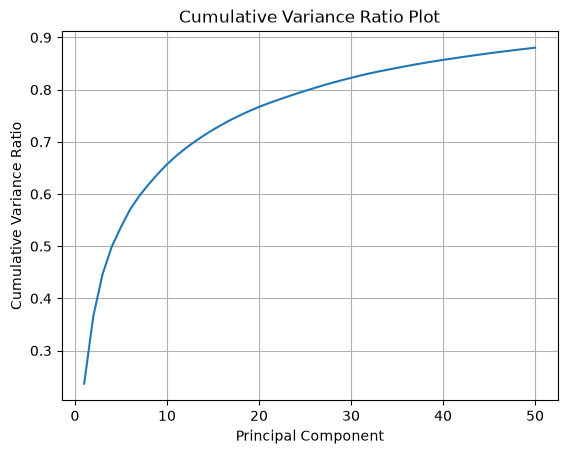

<IPython.core.display.Math object>

In [6]:
plt.plot(np.arange(1, N_COMPONENTS+1), np.cumsum(pca.explained_variance_ratio_))
plt.grid(True)
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Variance Ratio")
plt.title("Cumulative Variance Ratio Plot")
plt.show()

display(Math(r"$\text{Explained Variance by using }$"+f"${N_COMPONENTS}$"+r"$\text{ principal components is }$"+f"${np.round(np.cumsum(pca.explained_variance_ratio_)[-1]*100, 3)}$"+r"$\%$"))

# Testing our model:
Now we will use our `test_dataset` to test our model.

## Defining the function `euclidean_distance()`:
This function will calculate the euclidean distance $(\lvert\lvert f_{i}-f \rvert\rvert)$, where $f_{i}$ is the projected face from training dataset and $f$ is the projected face from test dataset.

In [7]:
def euclidean_distance(projection_matrix, transformed_test_image):
    return np.linalg.norm(projection_matrix - transformed_test_image, axis=1)

## Picking a test image:
We will pick a test image at random.

In [8]:
rng = np.random.default_rng(seed=144)
test_image_idx = rng.integers(0, TEST_PER_SUBJECT*N_SUBJECTS, size=1)
test_image_vector = test_dataset[test_image_idx]

## Finding closest match:
We will transform the test image using mean and eigenvectors of train dataset and then find the image that resembles with test image.

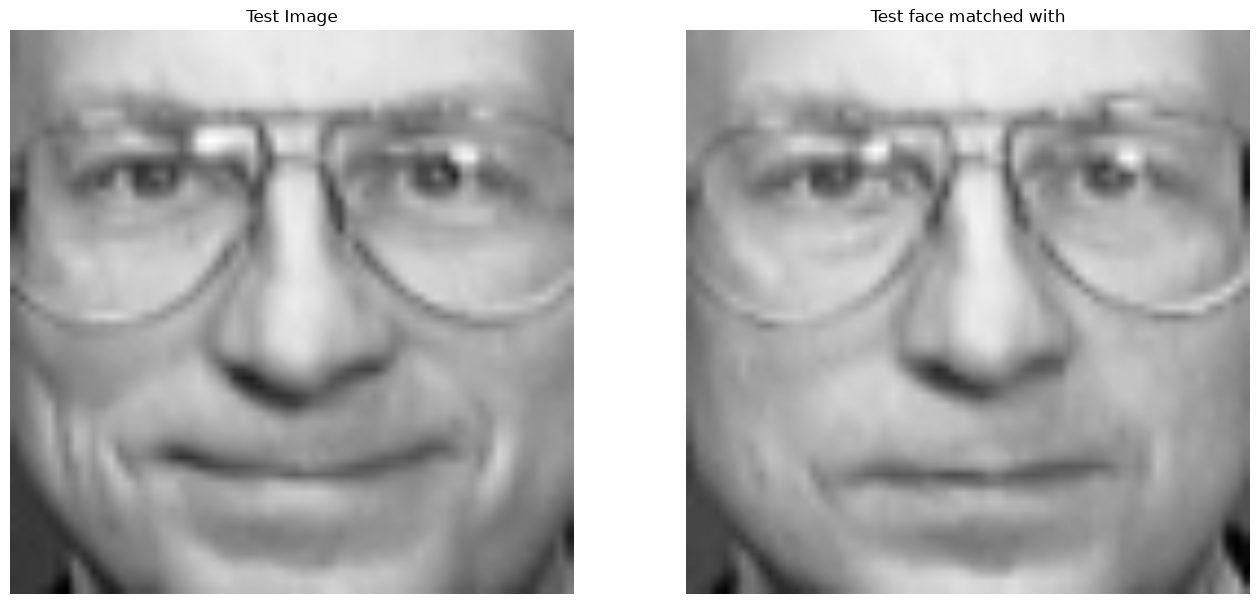

In [9]:
projection_of_test_image = pca.transform(test_image_vector)
distance = euclidean_distance(projection, projection_of_test_image)
min_distance_idx = np.argmin(distance)
closest_match_vector = train_dataset[min_distance_idx]

figure, axes = plt.subplots(1, 2, figsize=(16, 10))

axes[0].imshow(test_image_vector.reshape(IMG_SHAPE), cmap="gray", interpolation="bilinear")
axes[0].set_title("Test Image")
axes[0].axis("off")

axes[1].imshow(closest_match_vector.reshape(IMG_SHAPE), cmap="gray", interpolation="bilinear")
axes[1].set_title("Test face matched with")
axes[1].axis("off")

plt.show()

# Euclidean Distance Plot:
Here we will plot the euclidean distance vs index of image from training dataset.

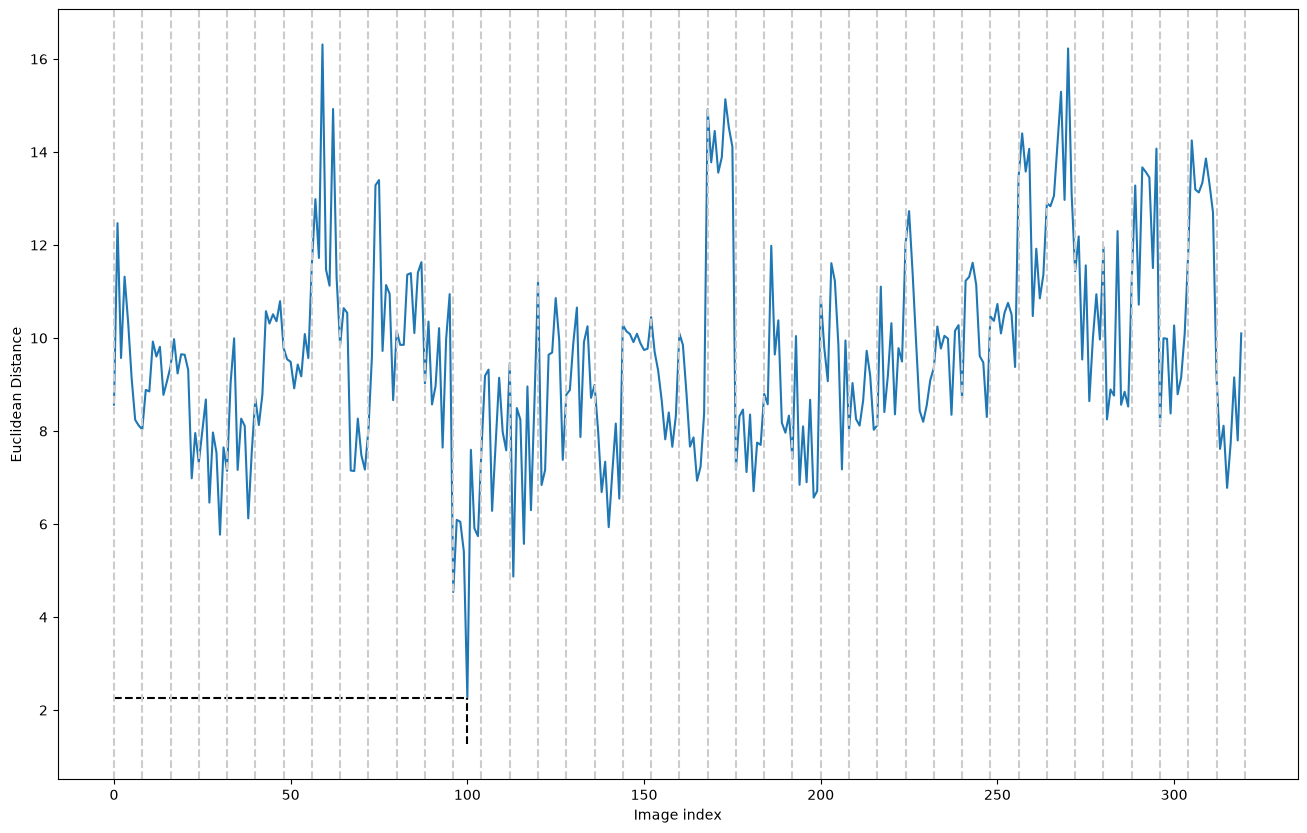

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [10]:
subject_size = np.arange(N_SUBJECTS*TRAIN_PER_SUBJECT+1, step=TRAIN_PER_SUBJECT)
plt.figure(figsize=(16, 10))
plt.plot(distance)
plt.hlines(distance[min_distance_idx], xmin=0, xmax=min_distance_idx, linestyle="--", color="black")
plt.vlines(min_distance_idx, ymin=distance[min_distance_idx]-1, ymax=distance[min_distance_idx], linestyle="--", color="black")
for border in subject_size:
    plt.axvline(border, linestyle="--", color="#cccccc")
plt.xlabel("Image index")
plt.ylabel("Euclidean Distance")
plt.show()

display(Math(r"$\text{Test image is from the subject }$"+f"${test_image_idx[0] // TEST_PER_SUBJECT}$"))
display(Math(r"$\text{Test image matched with images of subject }$"+f"${min_distance_idx // TRAIN_PER_SUBJECT}$"))
if test_image_idx[0] // TEST_PER_SUBJECT == min_distance_idx // TRAIN_PER_SUBJECT:
    display(Math(r"$\therefore\text{Prediction was accurate}$"))
else:
    display(Math(r"\therefore\text{Prediction was inaccurate}"))

# Some important metrics:
Since the test image is selected at random, there is a chance that the model did not show the failed case. Here we will take a look at Accuracy Score and Confusion Matrix.

First let us generate the prediction and true labels.

In [11]:
true_labels = np.repeat(np.arange(N_SUBJECTS), TEST_PER_SUBJECT)
predictions = []
for i in range(TEST_PER_SUBJECT*N_SUBJECTS):
    predictions.append(np.argmin(euclidean_distance(projection, pca.transform(test_dataset[i, :].reshape(1, -1)))) // TRAIN_PER_SUBJECT)

## Accuracy Score:

In [12]:
from sklearn.metrics import accuracy_score

accuracy = np.round(accuracy_score(true_labels, predictions), 3)*100
display(Math(r"\text{Accuracy Score}="+f"{accuracy}"+r"\%"))

<IPython.core.display.Math object>

## Confusion Matrix:

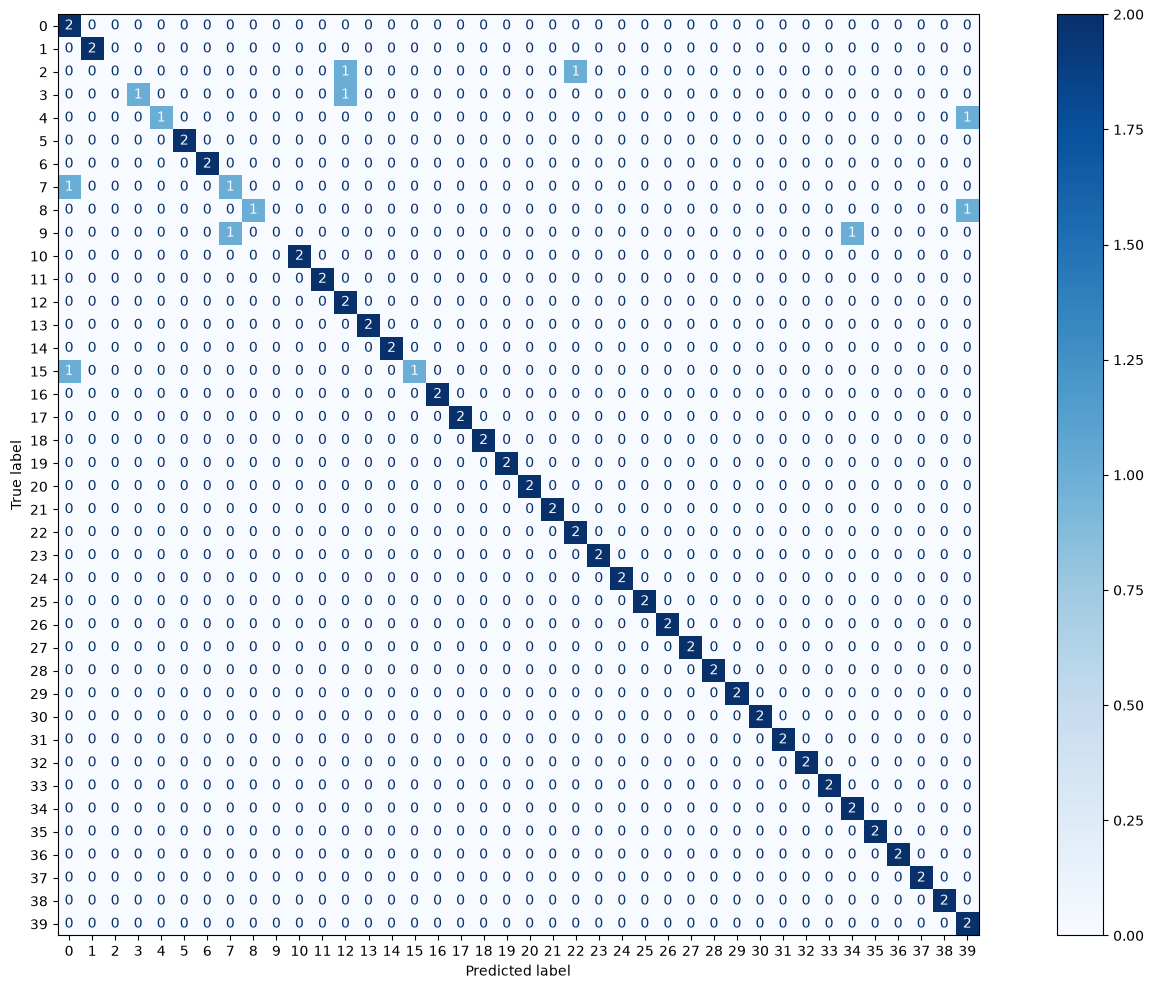

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(true_labels, predictions)
figure, ax = plt.subplots(figsize=(16, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(ax=ax, cmap=plt.cm.Blues)
plt.tight_layout()
plt.show()

From the above confusion matrix we can see that subjects 2 and 9 have 0% success and subjects 3, 4, 7, 8 and 15 have 50% success. Which means that all the test images (2 images) of subject 2 and 9 would fail, and half the test images (1 image) would fail on subjects 3, 4, 7, 8 and 15.

# Investigating the failure:

## Subjects 2 and 9:
Let us check what results in the test for subjects 2 and 9.

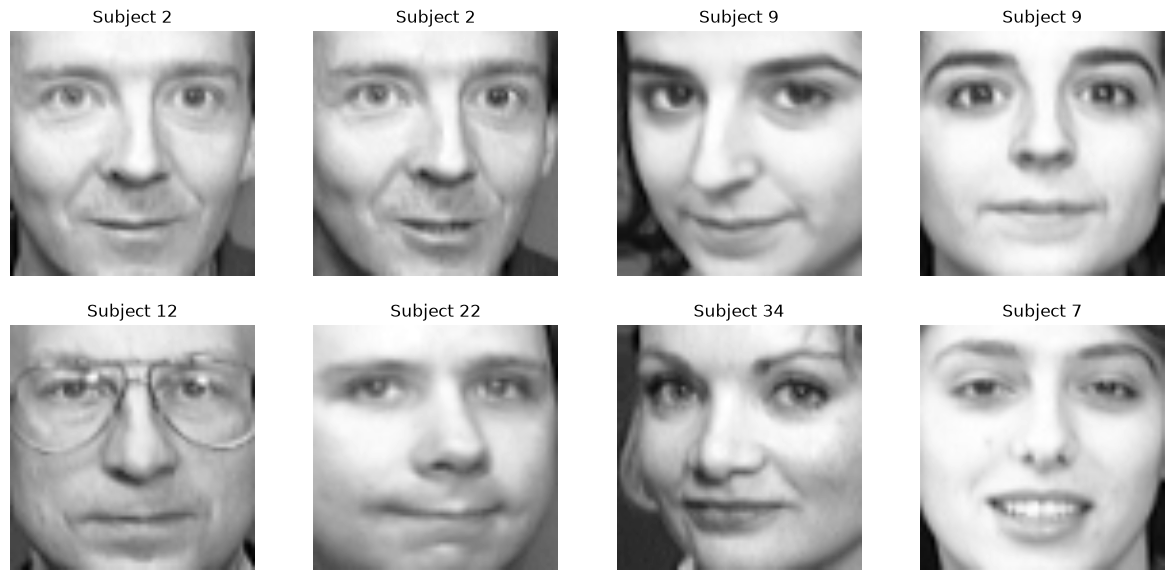

In [14]:
test_subjects = np.array([test_dataset[4:6].flatten(), test_dataset[18:20].flatten()]).reshape(4, IMG_SIZE)

figure, axes = plt.subplots(2, 4, figsize=(15, 7))
for i in range(4):
    test_image_vector = test_subjects[i, :].reshape(1, -1)
    projection_of_test_image = pca.transform(test_image_vector)
    distance = euclidean_distance(projection, projection_of_test_image)
    min_distance_idx = np.argmin(distance)
    closest_match_vector = train_dataset[min_distance_idx]
    axes[0, i].imshow(test_image_vector.reshape(IMG_SHAPE), cmap="gray", interpolation="bilinear")
    axes[0, i].set_title("Subject 2" if i < 2 else "Subject 9")
    axes[0, i].axis("off")
    
    axes[1, i].imshow(closest_match_vector.reshape(IMG_SHAPE), cmap="gray", interpolation="bilinear")
    axes[1, i].set_title(f"Subject {min_distance_idx // TRAIN_PER_SUBJECT}")
    axes[1, i].axis("off")

plt.show()

We can see that the model preserved the facial orientation but not facial features for these test images.

## Subjects 3, 4, 7, 8 and 15:

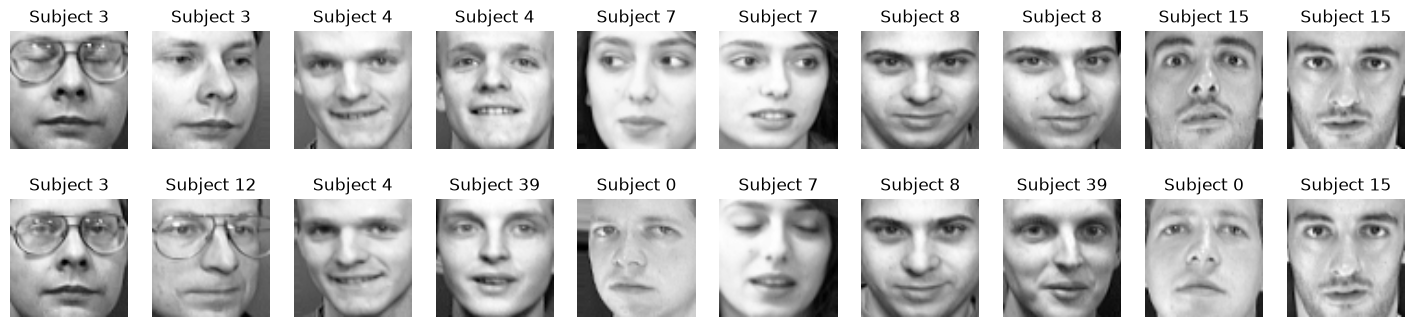

In [15]:
test_subjects = np.array([test_dataset[6:8, :].flatten(),
                          test_dataset[8:10, :].flatten(),
                          test_dataset[14:16, :].flatten(),
                          test_dataset[16:18, :].flatten(),
                          test_dataset[30:32, :].flatten()]).reshape(10, IMG_SIZE)

figure, axes = plt.subplots(2, 10, figsize=(18, 4))
for i in range(10):
    test_image_vector = test_subjects[i, :].reshape(1, -1)
    projection_of_test_image = pca.transform(test_image_vector)
    distance = euclidean_distance(projection, projection_of_test_image)
    min_distance_idx = np.argmin(distance)
    closest_match_vector = train_dataset[min_distance_idx]

    axes[0, i].imshow(test_image_vector.reshape(IMG_SHAPE), cmap="gray", interpolation="bilinear")
    axes[0, i].axis("off")
    if i < 2:
        axes[0, i].set_title("Subject 3")
    elif i < 4:
        axes[0, i].set_title("Subject 4")
    elif i < 6:
        axes[0, i].set_title("Subject 7")
    elif i < 8:
        axes[0, i].set_title("Subject 8")
    else:
        axes[0, i].set_title("Subject 15")

    axes[1, i].imshow(closest_match_vector.reshape(IMG_SHAPE), cmap="gray", interpolation="bilinear")
    axes[1, i].axis("off")
    axes[1, i].set_title(f"Subject {min_distance_idx // TRAIN_PER_SUBJECT}")

plt.show()

Even here the faces that were not predicted accurately, we can see that they preserved facial orientation, and lightning.

This is the limitation of facial recognition using PCA as it captures variance and not individual details.

# Summary:
PCA successfully reduces the dimensionality of face images while preserving the dominant facial structure. Using Euclidean nearest-neighbor classification in the PCA subspace achieves high recognition accuracy on the Olivetti Faces dataset. However, because PCA is an unsupervised dimensionality reduction technique, it does not explicitly maximize class separation, leading to confusion between visually similar individuals.